# Complementary Macroeconomics

# 9th Session

# Structural Breaks and on 3D plots in Python

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from fredapi import Fred
fred_function = Fred(api_key = 'my key')

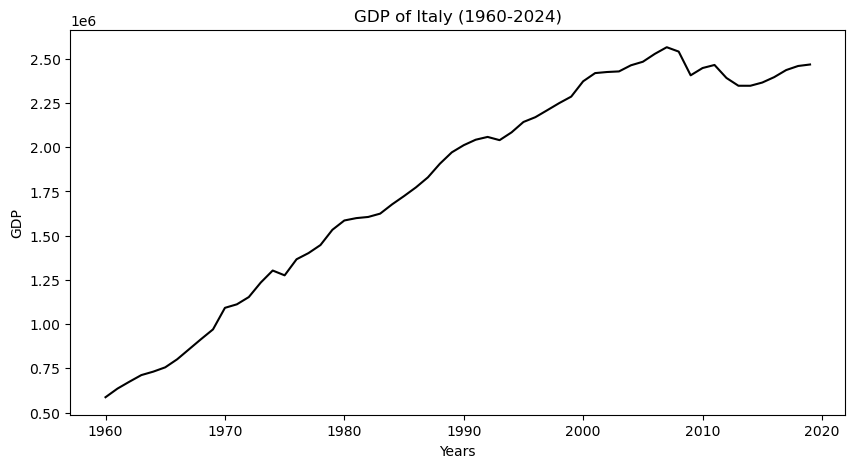

In [33]:
start_date = '1960-01-01'
end_date = '2024-01-01'

italy_gdp = fred_function.get_series("RGDPNAITA666NRUG", start_date, end_date)

plt.figure(figsize = (10, 5))
plt.plot(italy_gdp, color='black')
plt.title('GDP of Italy (1960-2024)')
plt.xlabel('Years')
plt.ylabel('GDP')
plt.show()

**In the third session, I attempted to make Italy's GDP stationary by differencing the series twice. After the first difference, the ADF test still indicated that the series was non-stationary. However, in the presence of structural breaks, ADF statistics can be misleading. This is where the Zivot-Andrews test becomes valuable—it accounts for endogenous structural breaks and provides a more reliable assessment of stationarity.**

In [ ]:
#pip install arch

In [128]:
from arch.unitroot import ZivotAndrews

ZA_test = ZivotAndrews(italy_gdp)
print(ZA_test.summary())

        Zivot-Andrews Results        
Test Statistic                 -3.670
P-value                         0.568
Lags                                0
-------------------------------------

Trend: Constant
Critical Values: -5.28 (1%), -4.81 (5%), -4.57 (10%)
Null Hypothesis: The process contains a unit root with a single structural break.
Alternative Hypothesis: The process is trend and break stationary.


## First Difference

In [130]:
italy_gdp_diff1 = italy_gdp.diff()
print(italy_gdp_diff1[0:5])

1960-01-01           NaN
1961-01-01    48749.5625
1962-01-01    38999.7500
1963-01-01    37374.6875
1964-01-01    19499.8125
Name: None, dtype: float64


In [132]:
italy_gdp_diff1 = italy_gdp.diff().dropna()
print(italy_gdp_diff1[0:5])

1961-01-01    48749.5625
1962-01-01    38999.7500
1963-01-01    37374.6875
1964-01-01    19499.8125
1965-01-01    24374.8750
Name: None, dtype: float64


In [134]:
from arch.unitroot import ZivotAndrews

ZA_test = ZivotAndrews(italy_gdp_diff1)
print(ZA_test.summary())

        Zivot-Andrews Results        
Test Statistic                 -6.574
P-value                         0.000
Lags                                1
-------------------------------------

Trend: Constant
Critical Values: -5.28 (1%), -4.81 (5%), -4.57 (10%)
Null Hypothesis: The process contains a unit root with a single structural break.
Alternative Hypothesis: The process is trend and break stationary.


# 3D Plots in Python

In [157]:
x = np.arange(1, 20)
y = np.random.randint(20, 500, len(x))

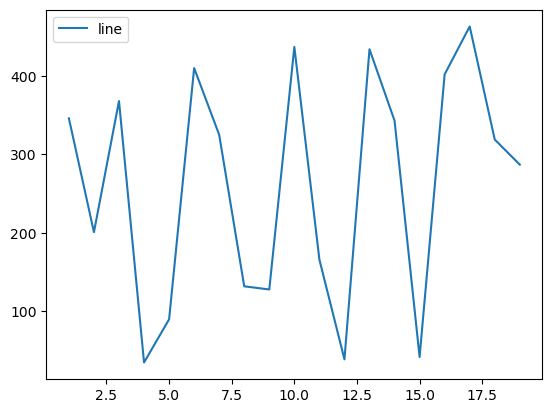

In [161]:
plt.plot(x, y, label = 'line')
plt.legend()
plt.show()

[]

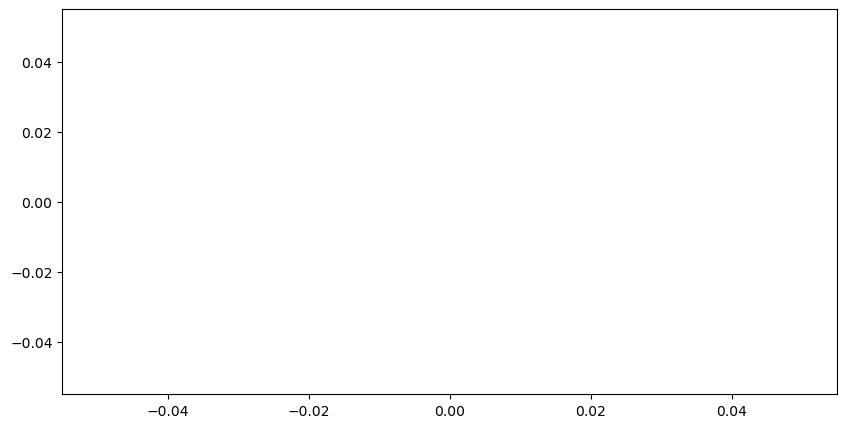

In [165]:
plt.figure(figsize = (10, 5))
plt.plot()

## Subplots

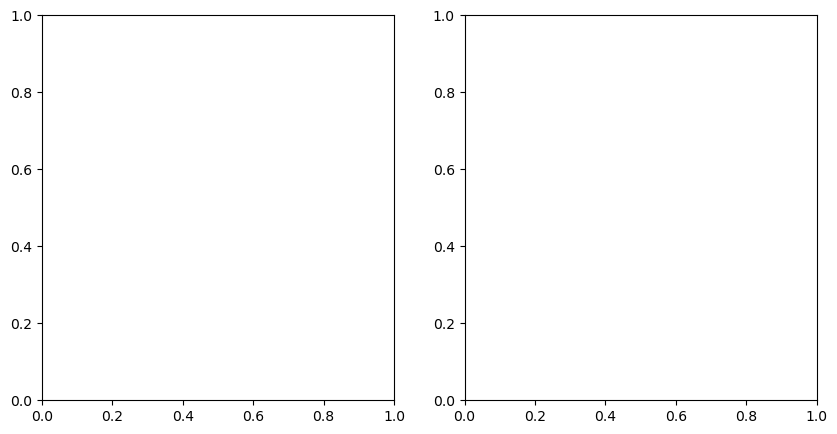

In [185]:
figure1 = plt.figure(figsize = (10, 5))

plot1 = figure1.add_subplot(121)
plot2 = figure1.add_subplot(122)
plt.show()

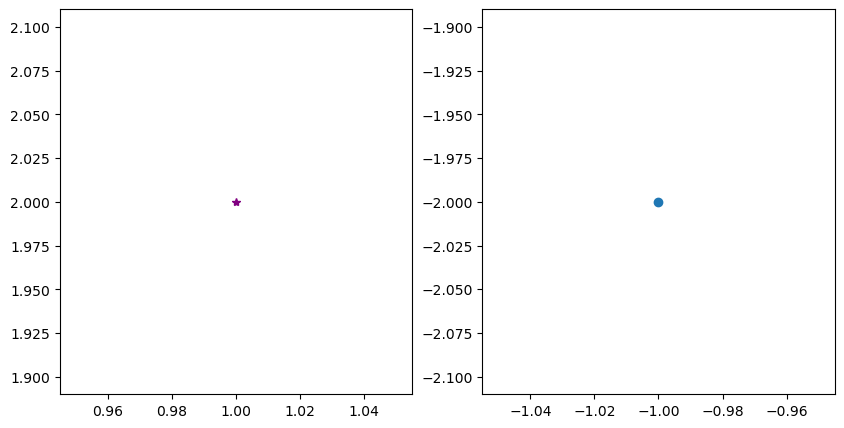

In [193]:
figure1 = plt.figure(figsize = (10, 5))

plot1 = figure1.add_subplot(121)
plt.plot(1,2, marker = '*', color = "purple")

plot2 = figure1.add_subplot(122)
plt.scatter(-1,-2)

plt.show()

## 3D space

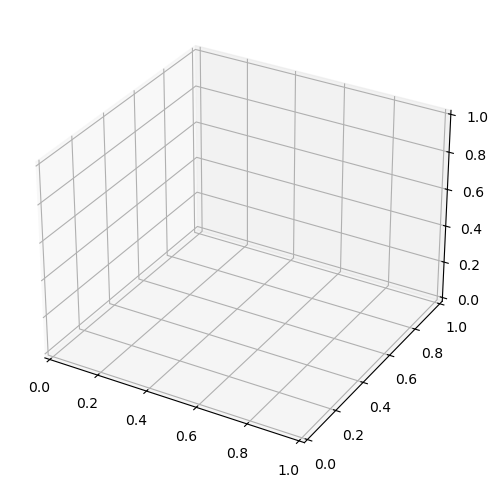

In [187]:
figure2 = plt.figure(figsize = (12,6))

plot_3d = figure2.add_subplot(111, projection = "3d")
plt.show()

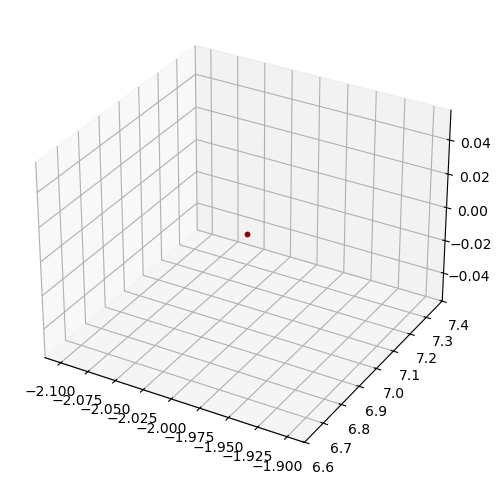

In [195]:
figure2 = plt.figure(figsize = (12,6))

plot_3d = figure2.add_subplot(111, projection = "3d")
plt.scatter(-2, 7, 10, marker = 'o', color = 'darkred')
plt.show()

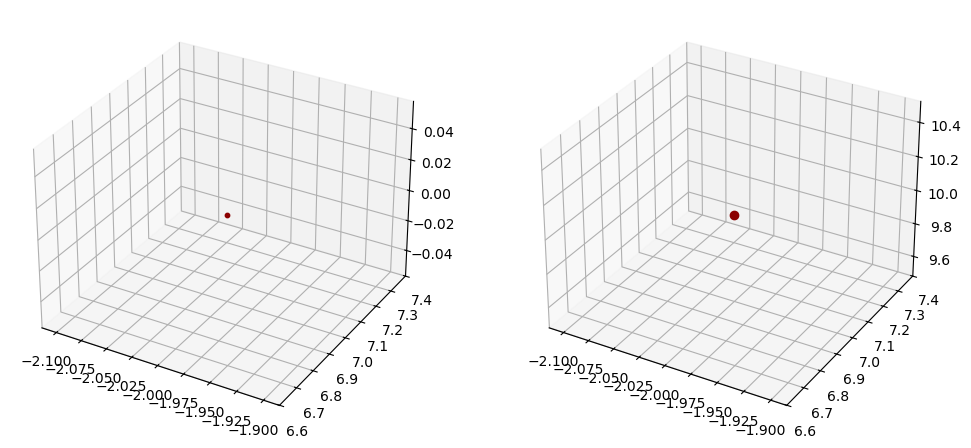

In [209]:
figure2 = plt.figure(figsize = (12,6))

plot_3d1 = figure2.add_subplot(121, projection = "3d")
plt.scatter(-2, 7, 10, marker = 'o', color = 'darkred')

plot_3d2 = figure2.add_subplot(122, projection = "3d")
plt.plot(-2, 7,10, marker = 'o', color = 'darkred')

#plt.subplots_adjust(wspace = 1, hspace = 1)
plt.show()

### using plt.plot()

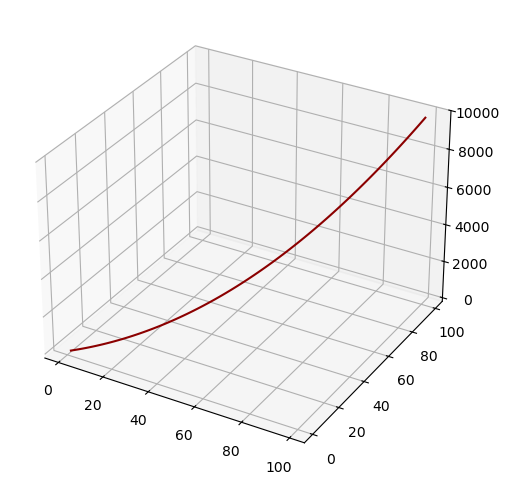

In [93]:
figure3 = plt.figure(figsize = (12,6))

plot_3d3 = figure3.add_subplot(111, projection = "3d")
x = np.arange(1,100)
y = np.arange(1, 100)
z = x * y

plt.plot(x, y, z, color = 'darkred')

plt.show()

In [237]:
def cobb_douglas(x, y):
    alpha = 0.5
    beta = 0.5
    return (x ** alpha) * (y ** beta)

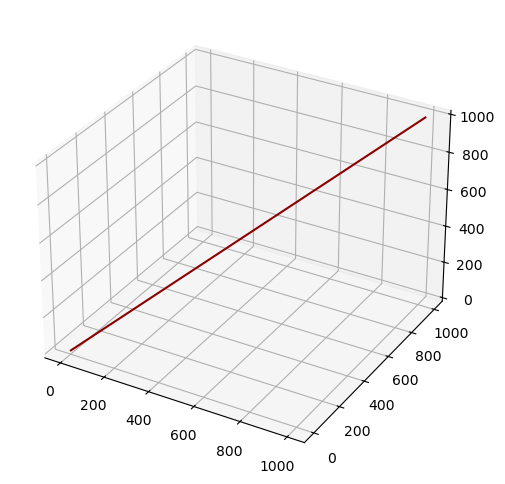

In [239]:
x1 = np.linspace(1, 1000, 500, dtype = "int")
y1 = np.linspace(1, 1000, 500, dtype = "int")

z = cobb_douglas(x1, y1)

figure4 = plt.figure(figsize = (12,6))
plot_3d4 = figure4.add_subplot(111, projection = "3d")

plt.plot(x1, y1, z, color = 'darkred')

plt.show()

### using plot_surface()

TypeError: Axes3D.plot_surface() missing 3 required positional arguments: 'X', 'Y', and 'Z'

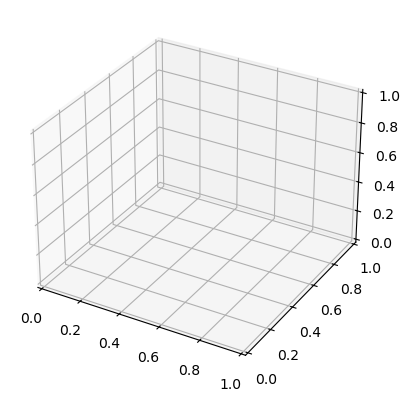

In [2]:
fig1 = plt.figure()

axis1 = fig1.add_subplot(111, projection = "3d")

axis1.plot_surface()
plt.show()

ValueError: Argument Z must be 2-dimensional.

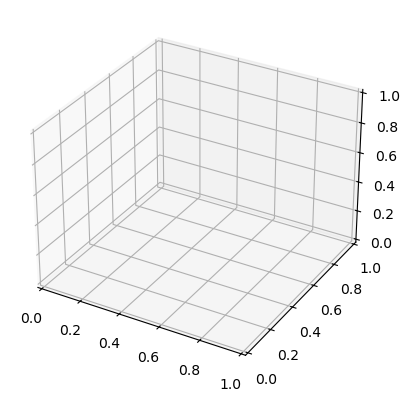

In [4]:
def cobb_douglas(x, y):
    alpha = 0.5
    beta = 0.5
    return (x ** alpha) * (y ** beta)

x1 = np.linspace(1, 1000, 500, dtype = "int")
y1 = np.linspace(1, 1000, 500, dtype = "int")

z = cobb_douglas(x1, y1)

fig1 = plt.figure()

axis1 = fig1.add_subplot(111, projection = "3d")

axis1.plot_surface(x1, y1, z)
plt.show()

# numpy.meshgrid()

In [9]:
q = np.arange(0, 5)
p = np.arange(0, 10)
print(q, p, sep = "\n")

[0 1 2 3 4]
[0 1 2 3 4 5 6 7 8 9]


In [11]:
Q, P = np.meshgrid(q, p)

In [13]:
print(Q, P, sep = "\n")

[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]
[[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]
 [5 5 5 5 5]
 [6 6 6 6 6]
 [7 7 7 7 7]
 [8 8 8 8 8]
 [9 9 9 9 9]]


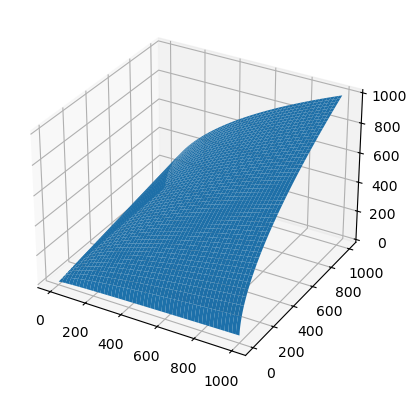

In [17]:
x1 = np.linspace(1, 1000, 500, dtype = "int")
y1 = np.linspace(1, 1000, 500, dtype = "int")

X1, Y1 = np.meshgrid(x1, y1)

Z = cobb_douglas(X1, Y1)

fig1 = plt.figure()

axis1 = fig1.add_subplot(111, projection = "3d")

axis1.plot_surface(X1, Y1, Z)
plt.show()

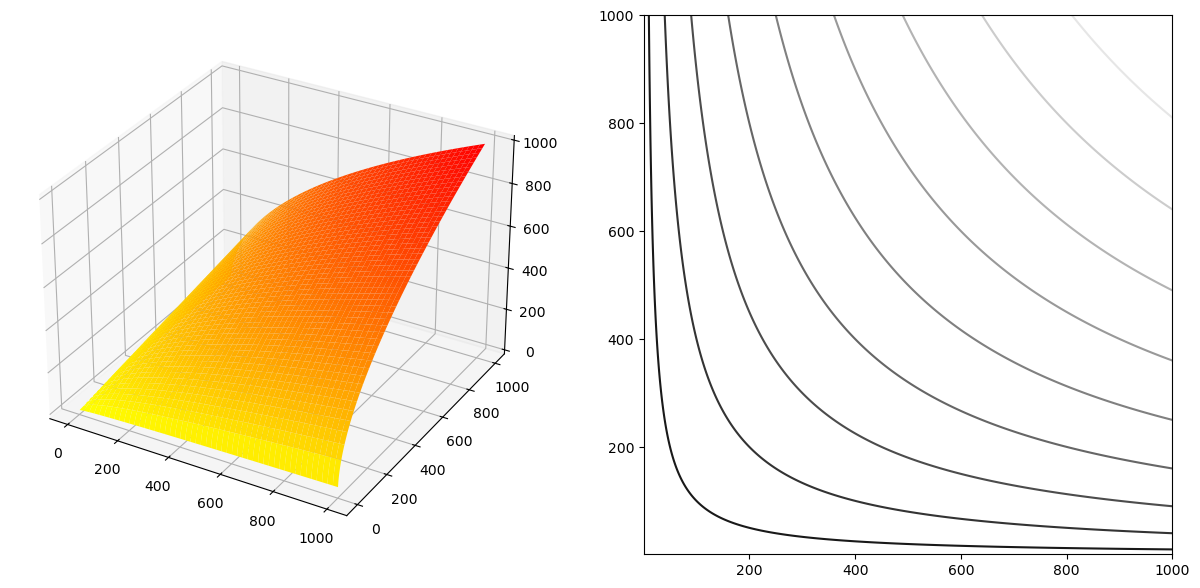

In [31]:
x1 = np.linspace(1, 1000, 500, dtype = "int")
y1 = np.linspace(1, 1000, 500, dtype = "int")

X1, Y1 = np.meshgrid(x1, y1)

Z = cobb_douglas(X1, Y1)

fig1 = plt.figure(figsize = (15, 7))

axis1 = fig1.add_subplot(121, projection = "3d")
axis1.plot_surface(X1, Y1, Z, cmap = "autumn_r")

axis2 = fig1.add_subplot(122)
axis2.contour(X1, Y1, Z, levels = 10, cmap = "binary_r")

plt.show()

In [111]:
from matplotlib import colormaps
#list(colormaps)

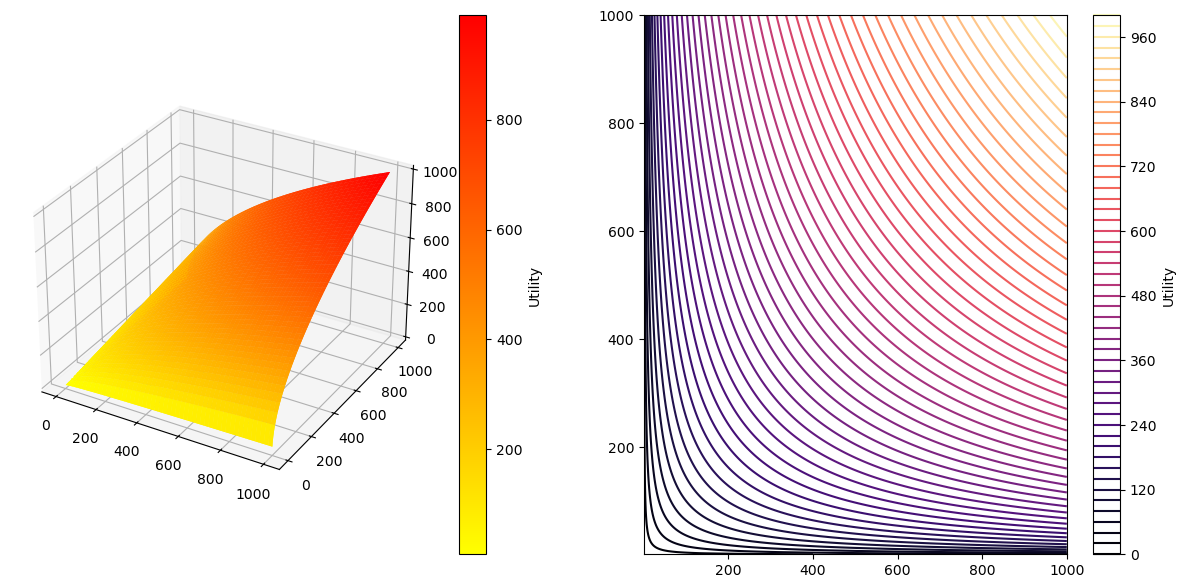

In [49]:
x1 = np.linspace(1, 1000, 500, dtype = "int")
y1 = np.linspace(1, 1000, 500, dtype = "int")

X1, Y1 = np.meshgrid(x1, y1)

Z = cobb_douglas(X1, Y1)

fig1 = plt.figure(figsize = (15, 7))

axis1 = fig1.add_subplot(121, projection = "3d")
axis1.plot_surface(X1, Y1, Z, cmap = "autumn_r")
plt.colorbar(axis1.plot_surface(X1, Y1, Z, cmap = "autumn_r"), ax = axis1, label = "Utility")

axis2 = fig1.add_subplot(122)
con = axis2.contour(X1, Y1, Z, levels = 50, cmap = "magma")
plt.colorbar(con, ax = axis2, label = "Utility")
plt.show()

## Defining CRRA utility function

In [55]:
def crra(c, theta):
    if theta == 1:
        return np.log(c)
    else:
        return (c ** (1 - theta)) / (1 - theta)

In [57]:
function_value = crra(5, 0.2)
print(function_value)

4.529872897985597


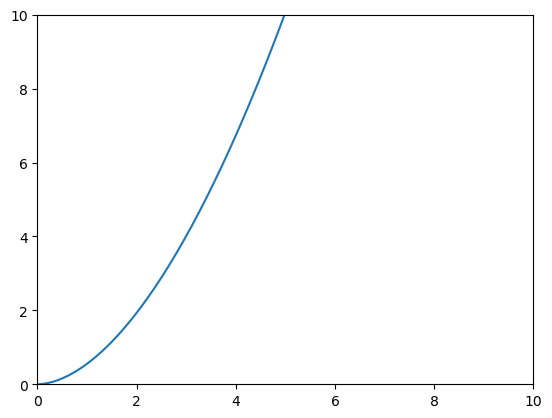

In [75]:
theta = -0.8
Consum = np.linspace(0.01, 50, 1000)
util_values = crra(Consum, theta)

plt.plot(Consum, util_values)
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.show()

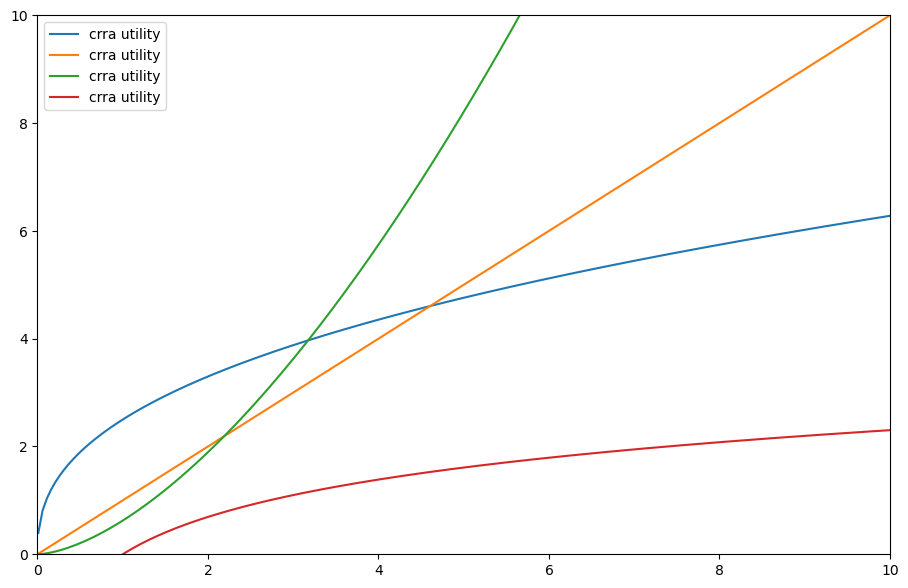

In [85]:
C = np.linspace(0.01, 50, 1000)
theta_values = [0.6, 0, -0.6, 1]

plt.figure(figsize = (11, 7))

for theta in theta_values:
    function_values = crra(C, theta)
    plt.plot(C, function_values, label = f"crra utility")
    
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.legend()
plt.show()

# Exercises

### 1. Apply the Zivot-Andrews test to some of the series from which you previously took differences for earlier exercises. Were the results of the ADF test and the ZA test similar?

### 2. Define a CES function, then plot its surface and contour.